In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from interpret.perf import ROC
from interpret.glassbox import LogisticRegression

# 1.Databetes

## 1-1 載入資料

In [3]:
df = pd.read_csv("../data/diabetes.csv")

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'BMI']
    
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1-2 分割特徵與標籤

In [4]:
y_d = df["Outcome"]
X_d = df.drop(columns=["Outcome"])

## 1-3 訓練/測試分割

In [5]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

In [6]:
X_train_d[cols] = X_train_d[cols].replace(0, pd.NA)
X_test_d[cols] = X_test_d[cols].replace(0, pd.NA)

for c in cols:
    median = X_train_d[c].median()
    X_train_d[c] = X_train_d[c].fillna(median)
    X_test_d[c] = X_test_d[c].fillna(median)

/var/folders/rk/_v3gn3692yd991_9sbypvgv00000gn/T/ipykernel_7822/4263429774.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_d[c] = X_train_d[c].fillna(median)
/var/folders/rk/_v3gn3692yd991_9sbypvgv00000gn/T/ipykernel_7822/4263429774.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_d[c] = X_test_d[c].fillna(median)
/var/folders/rk/_v3gn3692yd991_9sbypvgv00000gn/T/ipykernel_7822/4263429774.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infe

## 1-4 資料探索

In [7]:
from interpret.data import ClassHistogram

hist_diabetes = ClassHistogram().explain_data(X_train_d, y_train_d, name='daibetes')
show(hist_diabetes)

<!-- http://127.0.0.1:7243/5985188704/ -->

## 1-4 訓練 EBM

In [8]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train_d, y_train_d)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


## 1-5 效能評估/計算AUC

In [9]:
ebm_perf = ROC(ebm).explain_perf(X_test_d, y_test_d, name='EBM')
show(ebm_perf)

<!-- http://127.0.0.1:7243/6032426384/ -->

In [10]:
y_prob_d = ebm.predict_proba(X_test_d)[:, 1]
auc = roc_auc_score(y_test_d, y_prob_d)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.827


## 1-6 全域解釋

In [11]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6058113216/ -->

## 1-7 局部解釋

In [12]:
ebm_local = ebm.explain_local(X_test_d[:5], y_test_d[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6069874320/ -->

# 2.Heart

## 2-1 載入資料+前處理

In [13]:
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('../data/heart.csv', names=column_names, na_values='?')
df = df.dropna()
df['target'] = df['target'].apply(lambda x_h: 1 if x_h > 0 else 0)

## 2-2 分割特徵與標籤

In [14]:
y_h = df["target"]
X_h = df.drop(columns=["target"])

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2-3 訓練/測試分割

In [15]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

## 2-4 資料探索

In [16]:
from interpret.data import ClassHistogram

hist_heart = ClassHistogram().explain_data(X_train_h, y_train_h, name='heart')
show(hist_heart)

<!-- http://127.0.0.1:7243/6071384848/ -->

## 2-5 效能評估/計算AUC

In [17]:
ebm.fit(X_train_h, y_train_h)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [18]:
ebm_perf = ROC(ebm).explain_perf(X_test_h, y_test_h)
show(ebm_perf)

<!-- http://127.0.0.1:7243/6071381328/ -->

In [19]:
y_prob_h = ebm.predict_proba(X_test_h)[:, 1]
auc = roc_auc_score(y_test_h, y_prob_h)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.940


## 2-6 全域解釋

In [20]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6071371088/ -->

## 2-7 局部解釋

In [21]:
ebm_local = ebm.explain_local(X_test_h[:5], y_test_h[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6072536416/ -->

# 3.Stroke

## 3-1 載入資料

In [22]:
df = pd.read_csv("../data/stroke.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [23]:
df = df.drop(columns=["id"]).dropna()
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [24]:
num_cols = ['bmi', 'avg_glucose_level']
cat_cols = ['smoking_status']

In [25]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


## 3-2 分割特徵與標籤

In [26]:
y_s = df["stroke"]
X_s = df.drop(columns=["stroke"])
X_s = pd.get_dummies(X_s).astype(float)

## 3-3 訓練／測試分割

In [27]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42
)

In [28]:
# numeric imputation
for c in num_cols:
    if c in X_train_s.columns:
        median = X_train_s[c].median()
        X_train_s[c] = X_train_s[c].fillna(median)
        X_test_s[c] = X_test_s[c].fillna(median)

# categorical columns
cat_cols = ['smoking_status']
cat_cols = [c for c in cat_cols if c in X_train_s.columns]

for c in cat_cols:
    mode = X_train_s[c].mode()[0]
    X_train_s[c] = X_train_s[c].fillna(mode)
    X_test_s[c] = X_test_s[c].fillna(mode)

## 3-4 資料探索

In [29]:
from interpret.data import ClassHistogram

hist_stroke = ClassHistogram().explain_data(X_train_s, y_train_s, name='stroke')
show(hist_stroke)

<!-- http://127.0.0.1:7243/6073581968/ -->

## 3-5 效能評估/計算AUC

In [30]:
ebm.fit(X_train_s, y_train_s)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [31]:
ebm_perf = ROC(ebm).explain_perf(X_test_s, y_test_s)
show(ebm_perf)

<!-- http://127.0.0.1:7243/6073583888/ -->

In [32]:
y_prob_s = ebm.predict_proba(X_test_s)[:, 1]
auc = roc_auc_score(y_test_s, y_prob_s)
print(f"EBM Test AUC:{auc:.3f}")

EBM Test AUC:0.842


## 3-6 全域解釋

In [33]:
ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7243/6072544624/ -->

## 3-7 局部解釋

In [34]:
ebm_local = ebm.explain_local(X_test_s[:5], y_test_s[:5])
show(ebm_local, 0)

<!-- http://127.0.0.1:7243/6076683408/ -->

# 比較Dashboard

In [35]:
show([hist_heart, hist_stroke, hist_diabetes])

<!-- http://127.0.0.1:7243/6076506048/ -->
 Open in new window

# AUC對比表

In [36]:
from interpret.glassbox import LogisticRegression, ClassificationTree

lr_h = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_h.fit(X_train_h, y_train_h)

lr_s = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_s.fit(X_train_s, y_train_s)

lr_d = LogisticRegression(random_state=42, penalty='l1', solver='liblinear')
lr_d.fit(X_train_d, y_train_d)

In [37]:
from sklearn.metrics import roc_auc_score
import pandas as pd

def auc(model, X_test, y_test):
    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

auc_df = pd.DataFrame([
    ["Heart", auc(lr_h, X_test_h, y_test_h)],
    ["Stroke", auc(lr_s, X_test_s, y_test_s)],
    ["Diabetes", auc(lr_d, X_test_d, y_test_d)]
], columns=["Model", "AUC"])

auc_df

,Model,AUC
0,Heart,0.936343
1,Stroke,0.853728
2,Diabetes,0.823140


In [41]:
from interpret import show

ebm_global = ebm.explain_global()
data_dict = ebm_global.data()

In [42]:
for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    bins = data_dict.get('values', None)

    print("Feature name:", name)

    print("Scores type:", type(scores))
    print("Scores:", scores[:5] if hasattr(scores, '__len__') else scores)


================ Feature 0 ================
Feature name: age
Scores type: <class 'numpy.float64'>
Scores: 1.3875479090063858

================ Feature 1 ================
Feature name: hypertension
Scores type: <class 'numpy.float64'>
Scores: 0.10791323087804822

================ Feature 2 ================
Feature name: heart_disease
Scores type: <class 'numpy.float64'>
Scores: 0.060696525989182425

================ Feature 3 ================
Feature name: avg_glucose_level
Scores type: <class 'numpy.float64'>
Scores: 0.13750961335397463

================ Feature 4 ================
Feature name: bmi
Scores type: <class 'numpy.float64'>
Scores: 0.13423092241109263

================ Feature 5 ================
Feature name: gender_Female
Scores type: <class 'numpy.float64'>
Scores: 0.025381490299045028

================ Feature 6 ================
Feature name: gender_Male
Scores type: <class 'numpy.float64'>
Scores: 0.025632658856640286

================ Feature 7 ================
Featur

In [43]:
import numpy as np

for i in range(len(data_dict['names'])):

    print(f"\n================ Feature {i} ================")

    name = data_dict['names'][i]
    scores = data_dict['scores'][i]
    values = data_dict.get('values', None)

    print("Feature name:", name)


================ Feature 0 ================
Feature name: age

================ Feature 1 ================
Feature name: hypertension

================ Feature 2 ================
Feature name: heart_disease

================ Feature 3 ================
Feature name: avg_glucose_level

================ Feature 4 ================
Feature name: bmi

================ Feature 5 ================
Feature name: gender_Female

================ Feature 6 ================
Feature name: gender_Male

================ Feature 7 ================
Feature name: gender_Other

================ Feature 8 ================
Feature name: ever_married_No

================ Feature 9 ================
Feature name: ever_married_Yes

================ Feature 10 ================
Feature name: work_type_Govt_job

================ Feature 11 ================
Feature name: work_type_Never_worked

================ Feature 12 ================
Feature name: work_type_Private

================ Feature 13 ================

In [44]:
    # 判斷 numerical / categorical
    if isinstance(scores, np.ndarray) and scores.ndim == 1:

        print("\nType: Numerical")

        print("\n🔹 Key differences:")
        print("- density: continuous bin-based distribution")
        print("- type: continuous feature")
        print("- scores: per-bin effect values")

        print("\nExample scores (first 5):", scores[:5])

    else:

        print("\nType: Categorical")

        print("\n🔹 Key differences:")
        print("- density: discrete category-based distribution")
        print("- type: categorical encoding")
        print("- scores: per-category effect values")

        print("\nExample scores:", scores)


Type: Categorical

🔹 Key differences:
- density: discrete category-based distribution
- type: categorical encoding
- scores: per-category effect values

Example scores: 0.06835781548535395


In [49]:
X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)
X_test_d = X_test_d.reindex(columns=X_train_s.columns, fill_value=0)
X_test_h = X_test_h.reindex(columns=X_train_s.columns, fill_value=0)

In [53]:
X_test = pd.concat([X_test_s, X_test_d, X_test_h], axis=0)
X_test = X_test.reindex(columns=X_train_s.columns, fill_value=0)

In [55]:
ebm_global = ebm.explain_global()
data = ebm_global.data()

names = data['names']
scores = data['scores']

name0 = names[0]
score0 = scores[0]

In [56]:
ebm_local = ebm.explain_local(X_test[:50])

In [57]:
import numpy as np

bagged_scores = ebm_local.data(0)['scores']  # class 0 / feature 0
std = np.std(bagged_scores, axis=0)

In [58]:
ci_width = 1.96 * std

In [59]:
lower = ebm_local.data(0).get('lower_bounds', None)
upper = ebm_local.data(0).get('upper_bounds', None)

In [60]:
if lower is not None and upper is not None:
    empirical = (upper - lower) / 2
    diff_pct = np.mean(np.abs(empirical - ci_width) / (ci_width + 1e-8)) * 100
    print("CI difference %:", diff_pct)

In [62]:
#A3
ebm_global = ebm.explain_global()
data = ebm_global.data()

name0 = data['names'][0]
score0 = data['scores'][0]

In [63]:
print("len(names):", len(data['names']))
print("len(scores):", len(data['scores']))

len(names): 84
len(scores): 84


In [64]:
values0 = data.get('values', None)
if values0 is not None:
    print("bins:", len(values0[0]) if isinstance(values0[0], list) else "structured")

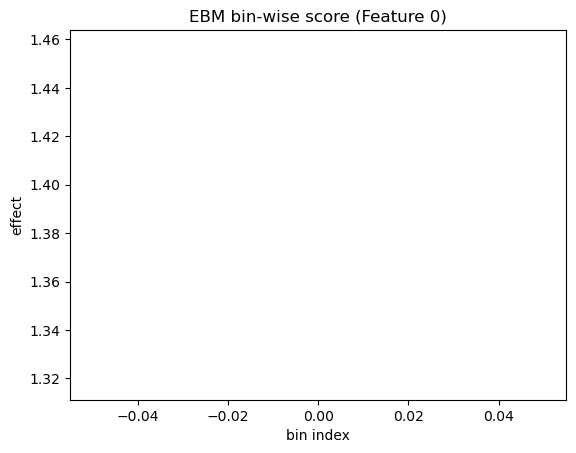

In [66]:
import matplotlib.pyplot as plt

plt.plot(score0)
plt.title("EBM bin-wise score (Feature 0)")
plt.xlabel("bin index")
plt.ylabel("effect")
plt.show()

In [69]:
print(type(score0))

import numpy as np

if isinstance(score0, (list, np.ndarray)):
    print(len(score0))
else:
    print("single value:", score0)

<class 'numpy.float64'>
single value: 1.3875479090063858
